# Modèle de recalage en python avec $SO(2)$

### Approche directe - Discrétiser puis Optimiser
Pour résoudre ce problème numériquement, on utilise un algorithme itératif :
- **Initialisation**: On choisit une vitesse angulaire de départ, par exemple $\omega^{(0)}=0$.
- **Boucle d'optimisation** (pour chaque itération $k$) :
    1. _Intégration du flot_ ([Méthode d'Euler explicite](https://fr.wikipedia.org/wiki/M%C3%A9thode_d%27Euler#Euler_explicite)) :
        On discrétise le temps physique $t\in [0,1]$ en $N$ sous-intervalles de pas $\Delta t$. En partant de la position initiale $x_{t=0}=x_S$, in intègre la dynamique pas à pas :
        $$
        x_{t+\Delta t}=x_{t}+\Delta tA(\omega^{(k)})x_t
        $$
        On obtient la position déformée finale $x_{finale}$ (qui correspond à l'instant $t=1$)
    2. _Évaluation de l’énergie_ : On calcule le coût global $J(\omega^{(k)})$.
    3. _Mise à jour_ ([Descente de gradient](https://fr.wikipedia.org/wiki/Algorithme_du_gradient)) : On calcule le gradient de l'énergie $\nabla J(\omega^{(k)})$ et on actualise la vitesse angulaire avec un taux d'apprentissage $\alpha$:
    $$
    \omega^{(k+1)}=\omega^{(k)}-\alpha\nabla J(\omega^{(k)})
    $$
La descente de gradient peut être fait avec l'algorithme [L-BFGS](https://docs.pytorch.org/docs/2.12/generated/torch.optim.LBFGS.html) de pytorch.

In [1]:
import torch
from torch.autograd import grad
import matplotlib.pyplot as plt
import numpy as np

## Fonctions pour le recalage rigide $SO(2)$

On souhaite toujours minimiser le problème suivant :
$$
\begin{aligned}
\min_{v\in L^2([0,1],V)}~&J(v)=\frac{1}{2}\int_{0}^{1}\|v_t\|_{V}^2\,dt+\|I_0\circ\varphi_1^{-1}-I_1\|\\
&\text{tel que }\left\{\begin{array}{ll}\dot{\varphi}_t=v_t\circ\varphi_t\\\varphi_0=Id\end{array}\right.
\end{aligned}
$$

On remplace le champ de vitesse LDDMM par un champ rigide $\dot{x}=A(\omega)x$, avec
$$
A(\omega)=\begin{pmatrix}0 & -\omega\\\omega & 0\end{pmatrix}\in\mathfrak{so}(2)
$$
Le paramètre $\omega\in\mathbb{R}$ est la vitesse angulaire.

Et on retrouve ce qu'on avait dans le chapitre "**Cas particuliers de $SO(2)$ et $SO(3)$**" :
$$
\begin{aligned}
\min_{\omega\in \mathbb{R}}&~J(\omega)=\frac{1}{2}|\omega|^2+\|x_1(\omega)-x_T\|\\
&\text{tel que }\left\{\begin{array}{ll}\dot{x}=A(\omega)x\\x_{t=0}=x_S\end{array}\right.
\end{aligned}
$$

`skew_matrix` construit la matrice anti-symétrique $A(\omega)$ pour $SO(2)$.

In [2]:
def skew_matrix(omega):
    A = torch.zeros((2, 2), dtype=omega.dtype, device=omega.device)
    A[0, 1] = -omega.squeeze()
    A[1, 0] = omega.squeeze()
    return A

### Étape 1 : _Intégration du flot_
`Euler` intègre le flot rigide par la méthode d'Euler explicite sur $t \in [0, 1]$ avec :
- `q0` : position initiale `(n_points, 2)`,
- `omega` : vitesse angulaire,
- `nt` : nombre de pas de temps après avoir discrétisé $t$.

In [3]:
def Euler(q0, omega, nt):
    dt = 1.0 / (nt - 1)
    q = q0.clone()
    A = skew_matrix(omega)
    
    Q = torch.zeros((q0.shape[0], q0.shape[1], nt), dtype=q0.dtype, device=q0.device)
    Q[:, :, 0] = q
    
    for t in range(1, nt):
        # Dynamique: \dot{x} = A(\omega)x -> x_{t+\Delta t}=x_{t}+\Delta tA(\omega^{(k)})x_t
        q = q + dt * (q @ A.T)
        Q[:, :, t] = q
        
    return q, Q

### Étape 2 : _Évaluation de l’énergie_

`rotation_loss` calcule l'énergie totale $J(\omega) =\frac{1}{2}{|\omega|}^2+$ `dataloss_fnc(q_finale)`

In [4]:
def rotation_loss(dataloss_fnc, nt):
    def loss(q0, omega):
        q_final, _ = Euler(q0, omega, nt)
        dloss = dataloss_fnc(q_final)
        reg = 0.5 * (omega ** 2)
        return 0.1 * reg + dloss
    return loss

### Étape 3 : _Mise à jour (Descente de gradient)_

`opti_rotation` optimisation de la vitesse angulaire $\omega$ par descente de gradient, avec :
- `loss_fnc` : fonction $J(\omega)$ incluant la régularisation,
- `eta` : contrôle la taille des pas pour la descente de gradient.

In [5]:
def opti_rotation(q0, loss_fnc, n_iter, eta, omega_init):
    omega = torch.tensor([omega_init], dtype=q0.dtype, device=q0.device, requires_grad=True)
    optimizer = torch.optim.LBFGS([omega], lr=eta, line_search_fn='strong_wolfe')
    losses = []

    def closure():
        optimizer.zero_grad()
        L = loss_fnc(q0, omega)
        L.backward()
        return L

    for i in range(n_iter):
        L = optimizer.step(closure)
        losses.append(L.item())

        print(f"Itération {i+1:3d} - Loss: {L.item():.6f} | Omega: {omega.item():.4f}")
        print(f"")

    return omega.detach(), losses

`GaussLinKernel` et `lossVarifoldCurve` :

In [6]:
def GaussLinKernel(sigma):
    '''
    Define "Gaussian-CauchyBinet" kernel :math:`(K(x,y,u,v)b)_i = \sum_j \exp(-\gamma\|x_i-y_j\|^2) \langle u_i,v_j \rangle^2 b_j`
    '''
    def fun(x, y, u, v, b):
        gamma = 1 / (sigma * sigma)
        D2 = ((x[:,None,:]-y[None,:,:])**2).sum(dim=2)
        K = (-D2 * gamma).exp() * (u[:,None,:] * v[None,:,:]).sum(dim=2) ** 2
        return K @ b
    return fun

def lossVarifoldCurve(FS, VT, FT, K):
    '''
    Fonction qui calcule la loss varifold entre une forme source et une forme cible.
    '''
    
    def get_center_length_tangents(F, V):
        V0, V1 = (
            V.index_select(0, F[:, 0]),
            V.index_select(0, F[:, 1]),
        )
        centers, tangents = .5*(V0+V1), (V1-V0)
        non_zero_rows = torch.any(tangents != 0, dim=1)
        centers, tangents = centers[non_zero_rows], tangents[non_zero_rows]
        length = (tangents**2).sum(dim=1)[:, None].sqrt()
        return centers, length, tangents/length

    CT, LT, TTn = get_center_length_tangents(FT, VT)
    cst = (LT * K(CT, CT, TTn, TTn, LT)).sum()

    def loss(VS):
        CS, LS, TSn = get_center_length_tangents(FS, VS)
        return (
            cst
            + (LS * K(CS, CS, TSn, TSn, LS)).sum()
            - 2 * (LS * K(CS, CT, TSn, TTn, LT)).sum()
        )

    return loss

<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/y0/hb71nmmj44q00c6dg_pngdtm0000gn/T/ipykernel_31953/3750961128.py:3: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  Define "Gaussian-CauchyBinet" kernel :math:`(K(x,y,u,v)b)_i = \sum_j \exp(-\gamma\|x_i-y_j\|^2) \langle u_i,v_j \rangle^2 b_j`


`find_best_init` trouve le meilleur `omega` pour commenver la descente de gradient et ne pas se retrouver dans un minimum local.

In [7]:
def find_best_init(q0, loss_fnc, n_samples=16):
    best_omega, best_loss = 0.0, float('inf')
    for val in np.linspace(-np.pi, np.pi, n_samples, endpoint=False):
        om = torch.tensor([val], dtype=q0.dtype, device=q0.device)
        with torch.no_grad():
            L = loss_fnc(q0, om).item()
        if L < best_loss:
            best_loss, best_omega = L, val
    return best_omega

## Configurations de la forme et optimisation de la rotation :

In [8]:
# torch type and device
use_cuda = torch.cuda.is_available()
torchdeviceId = torch.device("cuda:0") if use_cuda else "cpu"
torchdtype = torch.float64

n_s = 10  # Nombre de points source
n_t = 10  # Nombre de points target
time_shoot = 20  # Temps de shooting

#####################################################################
### Définition des points source et cible

# Source
VS = torch.cat((torch.zeros(n_s, 1), torch.linspace(0, 4, n_s).reshape(n_s, 1)), 1)
FS = torch.cat((torch.arange(0, n_s - 1).reshape(n_s - 1, 1), torch.arange(1, n_s).reshape(n_s - 1, 1)), dim=1)

# Cible
th = torch.linspace(0, 0.4 * torch.pi, n_t).reshape(n_t, 1) # Ajusté pour la rotation
VT = torch.cat((2.0 * torch.sin(th), torch.linspace(0, 4, n_t).reshape(n_t, 1)), 1)
FT = torch.cat((torch.arange(0, n_t - 1).reshape(n_t - 1, 1), torch.arange(1, n_t).reshape(n_t - 1, 1)), dim=1)

#####################################################################
# Transfert sur le Device

q0 = VS.clone().detach().to(dtype=torchdtype, device=torchdeviceId)
VT = VT.clone().detach().to(dtype=torchdtype, device=torchdeviceId)
FS = FS.clone().detach().to(dtype=torch.long, device=torchdeviceId)
FT = FT.clone().detach().to(dtype=torch.long, device=torchdeviceId)

#####################################################################
# Noyaux et Attache aux données

sigma = torch.tensor([1.5], dtype=torchdtype, device=torchdeviceId)
K_lin = GaussLinKernel(sigma) # Noyau pour l'espace des Varifolds

dataloss_varifold = lossVarifoldCurve(FS, VT, FT, K_lin)
loss_fnc = rotation_loss(dataloss_varifold, time_shoot)

# Optimisation
print("Début de l'optimisation de la rotation SO(2)...")
omega_opt, loss_history = opti_rotation(q0, loss_fnc, n_iter=100, eta=1e-1, omega_init=1)

# Trajectoire finale
q_final, Q_traj = Euler(q0, omega_opt, time_shoot)

Début de l'optimisation de la rotation SO(2)...
Itération   1 - Loss: 18.326215 | Omega: -0.4907

Itération   2 - Loss: 0.330080 | Omega: -0.4907

Itération   3 - Loss: 0.330080 | Omega: -0.4907

Itération   4 - Loss: 0.330080 | Omega: -0.4907

Itération   5 - Loss: 0.330080 | Omega: -0.4907

Itération   6 - Loss: 0.330080 | Omega: -0.4907

Itération   7 - Loss: 0.330080 | Omega: -0.4907

Itération   8 - Loss: 0.330080 | Omega: -0.4907

Itération   9 - Loss: 0.330080 | Omega: -0.4907

Itération  10 - Loss: 0.330080 | Omega: -0.4907

Itération  11 - Loss: 0.330080 | Omega: -0.4907

Itération  12 - Loss: 0.330080 | Omega: -0.4907

Itération  13 - Loss: 0.330080 | Omega: -0.4907

Itération  14 - Loss: 0.330080 | Omega: -0.4907

Itération  15 - Loss: 0.330080 | Omega: -0.4907

Itération  16 - Loss: 0.330080 | Omega: -0.4907

Itération  17 - Loss: 0.330080 | Omega: -0.4907

Itération  18 - Loss: 0.330080 | Omega: -0.4907

Itération  19 - Loss: 0.330080 | Omega: -0.4907

Itération  20 - Loss

## Affichage de la rotation :

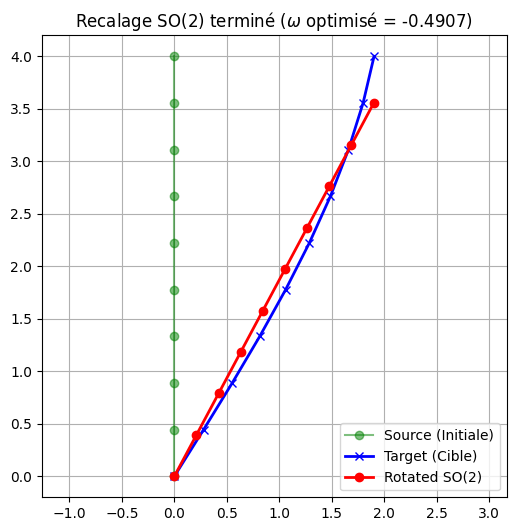

In [9]:
fig, ax = plt.subplots(figsize=(6, 6))

q0_np = q0.cpu().numpy()
q_final_np = q_final.cpu().numpy()
VT_np = VT.cpu().numpy()

# Plot Source
ax.plot(q0_np[:, 0], q0_np[:, 1], 'go-', label='Source (Initiale)', alpha=0.5)

# Plot Target
ax.plot(VT_np[:, 0], VT_np[:, 1], 'bx-', label='Target (Cible)', lw=2)

# Plot Final
ax.plot(q_final_np[:, 0], q_final_np[:, 1], 'ro-', label='Rotated SO(2)', lw=2)

ax.axis('equal')
ax.legend()
ax.set_title(rf"Recalage SO(2) terminé ($\omega$ optimisé = {omega_opt.item():.4f})")
plt.grid()
plt.show()

### Affichage de la rotation avec les étapes :

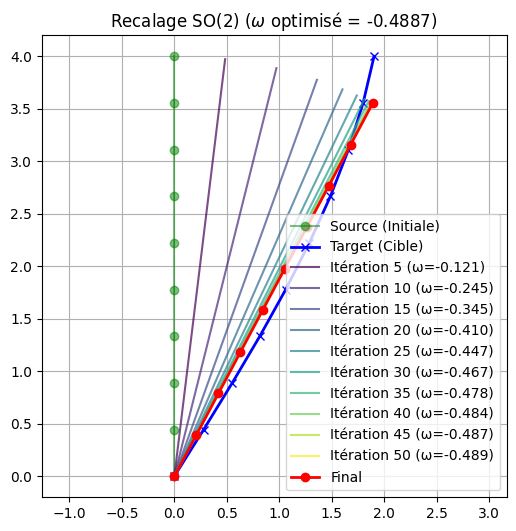

In [10]:
def opti_rotation2(q0, loss_fnc, n_iter, eta, save_iters=None):
    omega = torch.zeros(1, dtype=q0.dtype, device=q0.device, requires_grad=True)
    losses = []
    saved_omegas = []

    if save_iters is None:
        save_iters = []

    for i in range(n_iter):
        L = loss_fnc(q0, omega)
        losses.append(L.item())

        if omega.grad is not None:
            omega.grad.zero_()
        L.backward()

        with torch.no_grad():
            omega -= eta * omega.grad

        if (i + 1) in save_iters:
            saved_omegas.append((i + 1, omega.detach().clone()))

    return omega.detach(), losses, saved_omegas

n_iter = 50
save_iters = [int(n_iter * f) for f in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]]

omega_opt, loss_history, saved_omegas = opti_rotation2(q0, loss_fnc, n_iter, eta=1e-3, save_iters=save_iters)

fig, ax = plt.subplots(figsize=(6, 6))

q0_np = q0.cpu().numpy()
VT_np = VT.cpu().numpy()

# Plot Source
ax.plot(q0_np[:, 0], q0_np[:, 1], 'go-', label='Source (Initiale)', alpha=0.5)

# Plot Target
ax.plot(VT_np[:, 0], VT_np[:, 1], 'bx-', label='Target (Cible)', lw=2)

# Plot Iter
colors = plt.cm.viridis(np.linspace(0, 1, len(saved_omegas)))
for (it, om), c in zip(saved_omegas, colors):
    q_it, _ = Euler(q0, om, time_shoot)
    q_it_np = q_it.cpu().numpy()
    ax.plot(q_it_np[:, 0], q_it_np[:, 1], '-', color=c, alpha=0.7, label=f'Itération {it} (ω={om.item():.3f})')

# Plot Final
q_final, Q_traj = Euler(q0, omega_opt, time_shoot)
q_final_np = q_final.cpu().numpy()
ax.plot(q_final_np[:, 0], q_final_np[:, 1], 'ro-', label='Final', lw=2)

ax.axis('equal')
ax.legend()
ax.set_title(rf"Recalage SO(2) ($\omega$ optimisé = {omega_opt.item():.4f})")
plt.grid()
plt.show()

## Configurations de la forme et optimisation de la rotation (PNG) :

In [11]:
png_source_path = "../Images/coqS0.png"
png_target_path = "../Images/coqT1.png" #Essayer aussi avec coqT1.png, coqT2.png et coqT3.png

In [12]:
# torch type and device
use_cuda = torch.cuda.is_available()
torchdeviceId = torch.device("cuda:0") if use_cuda else "cpu"
torchdtype = torch.float64

time_shoot = 100  # Temps de shooting

#####################################################################
### Définition des points source et cible

from extract_contour import extract_contour_torch
from extract_contour import rot2d

source_points, edges_source = extract_contour_torch(png_source_path, 128, 0.5)
target_points, edges_target = extract_contour_torch(png_target_path, 128, 0.5)

R = rot2d(torch.tensor(torch.pi))

center = torch.mean(source_points, dim=0)
source_points = source_points - center
center = torch.mean(target_points, dim=0)
target_points = target_points - center

scale = source_points.std()
source_points = torch.einsum('ij,kj->ki', R, source_points / scale)
target_points = torch.einsum('ij,kj->ki', R, target_points / scale)

#####################################################################
# Transfert sur le Device

# Source
q0 = source_points.clone().detach().to(dtype=torchdtype, device=torchdeviceId)
FS = edges_source.clone().detach().to(dtype=torch.long, device=torchdeviceId)

# Cible
VT = target_points.clone().detach().to(dtype=torchdtype, device=torchdeviceId)
FT = edges_target.clone().detach().to(dtype=torch.long, device=torchdeviceId)

#####################################################################
# Noyaux et Attache aux données

sigma = torch.tensor([2], dtype=torchdtype, device=torchdeviceId)
K_lin = GaussLinKernel(sigma) # Noyau pour l'espace des Varifolds

dataloss_varifold = lossVarifoldCurve(FS, VT, FT, K_lin)
loss_fnc = rotation_loss(dataloss_varifold, time_shoot)

# Optimisation
print("Début de l'optimisation de la rotation SO(2)...")
omega_init = find_best_init(q0, loss_fnc)
omega_opt, loss_history = opti_rotation(q0, loss_fnc, n_iter=100, eta=1e-1, omega_init=omega_init)

# Trajectoire finale
q_final, Q_traj = Euler(q0, omega_opt, time_shoot)

Début de l'optimisation de la rotation SO(2)...
Itération   1 - Loss: 0.403210 | Omega: 0.7001

Itération   2 - Loss: 0.269002 | Omega: 0.7021

Itération   3 - Loss: 0.268901 | Omega: 0.7023

Itération   4 - Loss: 0.268899 | Omega: 0.7024

Itération   5 - Loss: 0.268899 | Omega: 0.7024

Itération   6 - Loss: 0.268899 | Omega: 0.7024

Itération   7 - Loss: 0.268899 | Omega: 0.7024

Itération   8 - Loss: 0.268899 | Omega: 0.7024

Itération   9 - Loss: 0.268899 | Omega: 0.7024

Itération  10 - Loss: 0.268899 | Omega: 0.7024

Itération  11 - Loss: 0.268899 | Omega: 0.7024

Itération  12 - Loss: 0.268899 | Omega: 0.7024

Itération  13 - Loss: 0.268899 | Omega: 0.7024

Itération  14 - Loss: 0.268899 | Omega: 0.7024

Itération  15 - Loss: 0.268899 | Omega: 0.7024

Itération  16 - Loss: 0.268899 | Omega: 0.7024

Itération  17 - Loss: 0.268899 | Omega: 0.7024

Itération  18 - Loss: 0.268899 | Omega: 0.7024

Itération  19 - Loss: 0.268899 | Omega: 0.7024

Itération  20 - Loss: 0.268899 | Omega: 

## Affichage de la rotation (PNG) :

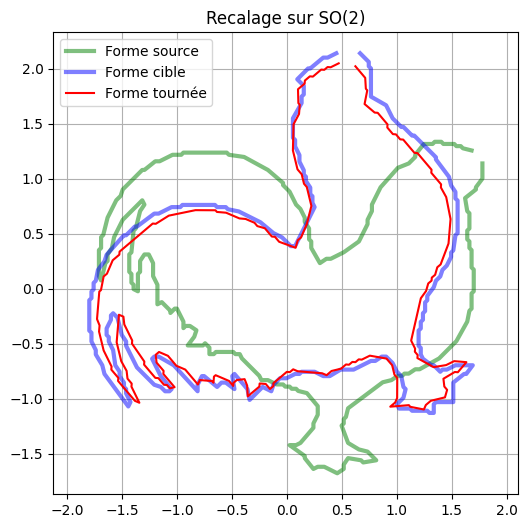

In [13]:
fig, ax = plt.subplots(figsize=(6, 6))

q0_np = q0.cpu().numpy()
q_final_np = q_final.cpu().numpy()
VT_np = VT.cpu().numpy()

# Plot Source
ax.plot(q0_np[:, 0], q0_np[:, 1], 'g-', label='Forme source', lw=3, alpha=0.5)

# Plot Target
ax.plot(VT_np[:, 0], VT_np[:, 1], 'b-', label='Forme cible', lw=3, alpha=0.5)

# Plot Final
ax.plot(q_final_np[:, 0], q_final_np[:, 1], 'r-', label='Forme tournée')

ax.axis('equal')
ax.legend()
ax.set_title(rf"Recalage sur SO(2)")
plt.grid()
plt.show()

### Autre affichages

In [14]:
q0_np = q0.cpu().numpy()
q_final_np = q_final.cpu().numpy()
VT_np = VT.cpu().numpy()
Q_traj_np = Q_traj.cpu().numpy()

xmin, xmax = VT_np[:, 0].min() - 0.5, VT_np[:, 0].max() + 0.5
ymin, ymax = VT_np[:, 1].min() - 0.5, VT_np[:, 1].max() + 0.5
grid_x, grid_y = np.meshgrid(np.linspace(xmin, xmax, 20), np.linspace(ymin, ymax, 20))
grid_points = np.vstack([grid_x.ravel(), grid_y.ravel()]).T
grid_tensor = torch.tensor(grid_points, dtype=torchdtype, device=torchdeviceId)

_, Grid_traj = Euler(grid_tensor, omega_opt, time_shoot)
Grid_traj_np = Grid_traj.cpu().numpy()

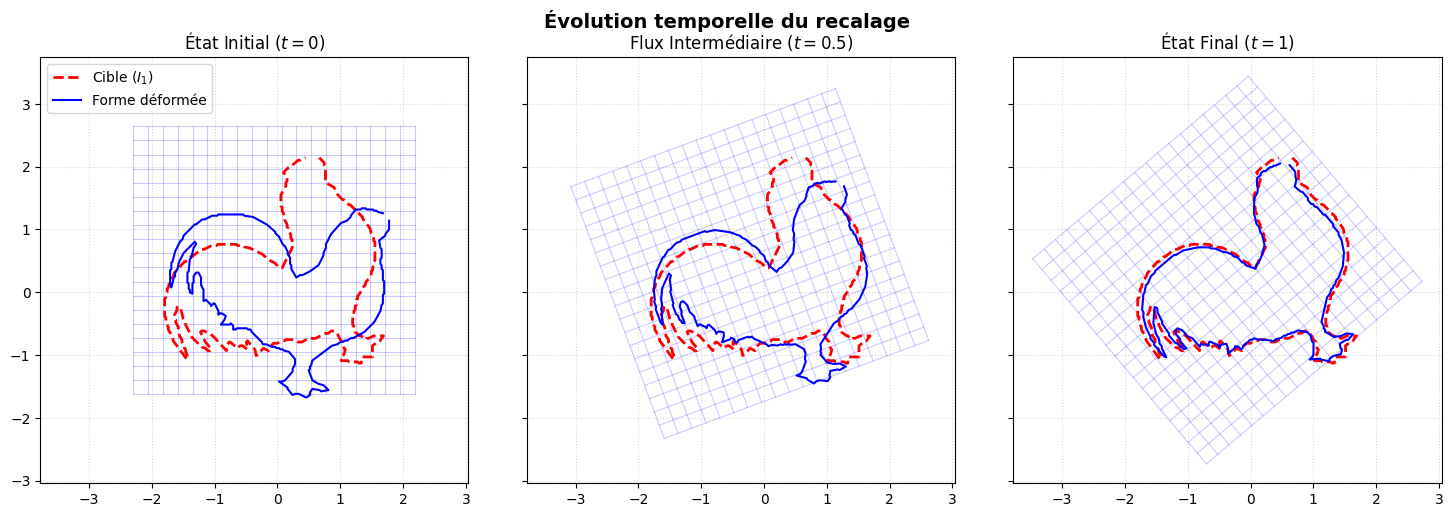

In [15]:
fig1, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
time_steps = [0, time_shoot // 2, time_shoot - 1]
titles = ["État Initial ($t=0$)", "Flux Intermédiaire ($t=0.5$)", "État Final ($t=1$)"]

for idx, t in enumerate(time_steps):
    ax = axes[idx]
    
    g_current = Grid_traj_np[:, :, t].reshape(20, 20, 2)
    for i in range(20):
        ax.plot(g_current[i, :, 0], g_current[i, :, 1], color='blue', alpha=0.2, lw=0.8)
        ax.plot(g_current[:, i, 0], g_current[:, i, 1], color='blue', alpha=0.2, lw=0.8)
        
    ax.plot(VT_np[:, 0], VT_np[:, 1], 'r--', label='Cible ($I_1$)' if idx==0 else "", lw=2)
    
    q_current = Q_traj_np[:, :, t]
    ax.plot(q_current[:, 0], q_current[:, 1], 'b-', label='Forme déformée' if idx==0 else "")
    
    ax.set_title(titles[idx], fontsize=12)
    
    ax.set_aspect('equal', adjustable='box') 
    
    if idx == 0:
        ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)

fig1.suptitle("Évolution temporelle du recalage", fontsize=14, fontweight='bold')
plt.tight_layout()

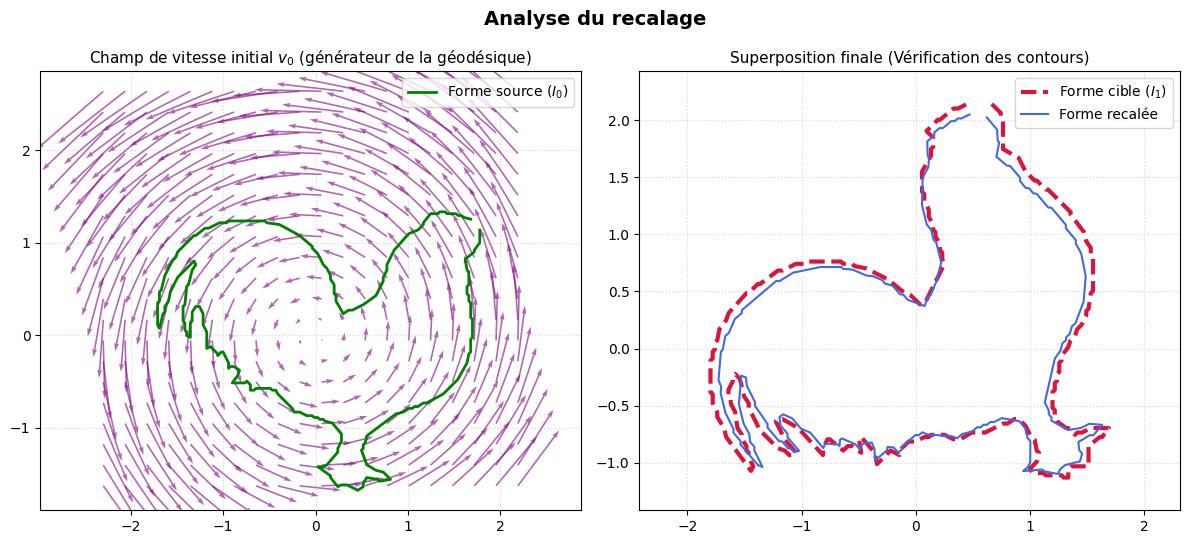

In [16]:
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5))

A_opt = skew_matrix(omega_opt).cpu().numpy()
g_sub = Grid_traj_np[:, :, 0]
v_0 = g_sub @ A_opt.T

ax1.quiver(g_sub[:, 0], g_sub[:, 1], v_0[:, 0], v_0[:, 1], color='purple', alpha=0.6, scale=15)
ax1.plot(q0_np[:, 0], q0_np[:, 1], 'g-', lw=2, label='Forme source ($I_0$)')
ax1.set_title("Champ de vitesse initial $v_0$ (générateur de la géodésique)", fontsize=11)
ax1.axis('equal')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.5)

ax2.plot(VT_np[:, 0], VT_np[:, 1], color='crimson', linestyle='--', lw=3, label='Forme cible ($I_1$)')
ax2.plot(q_final_np[:, 0], q_final_np[:, 1], color='royalblue', linestyle='-', lw=1.5, label='Forme recalée')
ax2.set_title("Superposition finale (Vérification des contours)", fontsize=11)
ax2.axis('equal')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.5)

fig2.suptitle("Analyse du recalage", fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()